In [25]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

In [26]:
# -----------------------------
# 1. Create datasets
# -----------------------------

AND = np.array([[1,1],[1,0],[0,1],[0,0]])
AND_y = np.array([[1],[0],[0],[0]])

OR = np.array([[1,1],[1,0],[0,1],[0,0]])
OR_y = np.array([[1],[1],[1],[0]])

XOR = np.array([[1,1],[1,0],[0,1],[0,0]])
XOR_y = np.array([[0],[1],[1],[0]])

In [27]:
# Convert to tensors
AND_X = torch.tensor(AND, dtype=torch.float32)
AND_y = torch.tensor(AND_y, dtype=torch.float32)

OR_X = torch.tensor(OR, dtype=torch.float32)
OR_y = torch.tensor(OR_y, dtype=torch.float32)

XOR_X = torch.tensor(XOR, dtype=torch.float32)
XOR_y = torch.tensor(XOR_y, dtype=torch.float32)

In [28]:
# -----------------------------
# 2. Define Perceptron
# -----------------------------

class Perceptron(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(2, 1)

    def forward(self, x):
        return self.linear(x)  # logits


In [29]:
# -----------------------------
# 3. Training function
# -----------------------------

def train_model(X, y, epochs=100):
    model = Perceptron()
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

    for epoch in range(epochs):
        output = model(X)
        loss = criterion(output, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    return model

# Train models
model_and = train_model(AND_X, AND_y)
model_or = train_model(OR_X, OR_y)
model_xor = train_model(XOR_X, XOR_y)

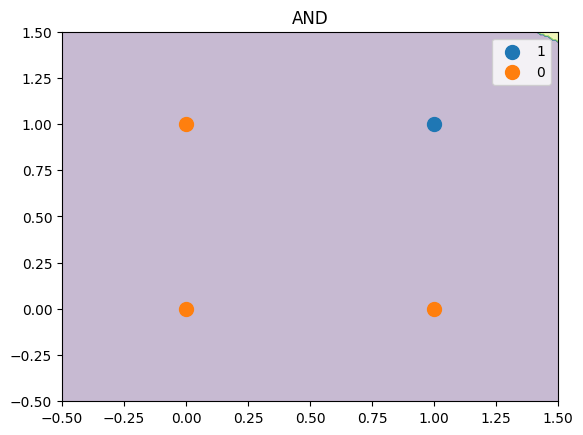

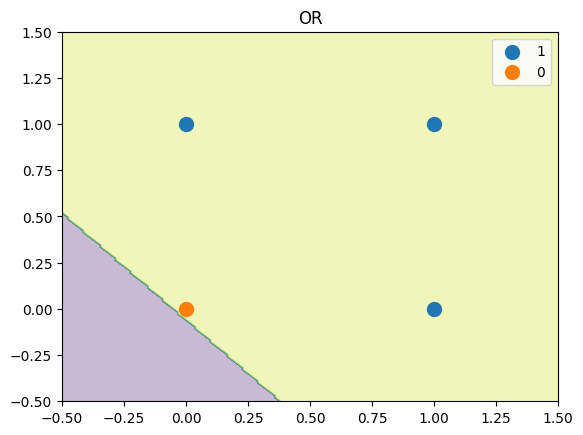

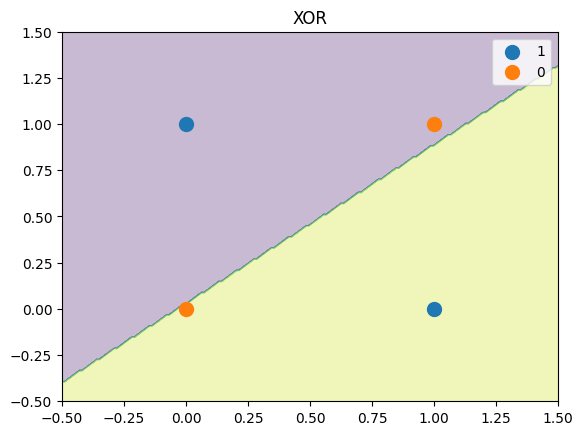

In [30]:
# -----------------------------
# 4. Decision boundary plot
# -----------------------------

def plot_decision_boundary(model, X, y, title):
    X_np = X.numpy()
    y_np = y.numpy().flatten()

    # Mesh grid
    x_min, x_max = -0.5, 1.5
    y_min, y_max = -0.5, 1.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    grid_tensor = torch.tensor(grid, dtype=torch.float32)

    with torch.no_grad():
        logits = model(grid_tensor)
        preds = (torch.sigmoid(logits) >= 0.5).float().numpy()

    Z = preds.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X_np[y_np==1][:,0], X_np[y_np==1][:,1], label="1", s=100)
    plt.scatter(X_np[y_np==0][:,0], X_np[y_np==0][:,1], label="0", s=100)

    plt.title(title)
    plt.legend()
    plt.show()

# Plot results
plot_decision_boundary(model_and, AND_X, AND_y, "AND")
plot_decision_boundary(model_or, OR_X, OR_y, "OR")
plot_decision_boundary(model_xor, XOR_X, XOR_y, "XOR")

In [19]:
xor_data

,input1,input2,ouput
0,1,1,0
1,1,0,1
2,0,1,1
3,0,0,0


In [21]:
# Convert to tensors
x_tensor = torch.tensor(or_data, dtype=torch.float32)  # PyTorch only works with tensors, not numpy arrays.
y_tensor = torch.tensor(and_data, dtype=torch.float32)
z_tensor = torch.tensor(xor_data, dtype=torch.float32).view(-1, 1) 

# Scatter Plot (Visualization)
plt.scatter(or_data["input1"], or_data["input2"], label="or", marker='o')
plt.scatter(and_data["input1"], and_data["input2"], label="and", marker='x')
plt.scatter(xor_data["input1"], and_data["input2"], label="and", marker='-')

# Labels
plt.xlabel("Input1")
plt.ylabel("Input2")
plt.title("Scatter Plot of Gates")

# Legend
plt.legend()

# Show plot
plt.show()

ValueError: could not determine the shape of object type 'DataFrame'